# Loading Lists

In [1]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

In [2]:
pd.options.mode.chained_assignment = None

In [3]:
plt.rcParams['font.family'] = 'Georgia'  # or another serif for editorial feel
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['figure.facecolor'] = 'white'

In [4]:
# NVDA has not reported earnings yet

with open('AAPL_list.pkl', 'rb') as file:
    aapl = pickle.load(file)

with open('MSFT_list.pkl', 'rb') as file:
    msft = pickle.load(file)

with open('AMZN_list.pkl', 'rb') as file:
    amzn = pickle.load(file)

with open('GOOGL_list.pkl', 'rb') as file:
    googl = pickle.load(file)

with open('META_list.pkl', 'rb') as file:
    meta = pickle.load(file)

with open('NVDA_list.pkl', 'rb') as file:
    nvda = pickle.load(file)
    
with open('TSLA_list.pkl', 'rb') as file:
    tsla = pickle.load(file)

dfs = [aapl, msft, amzn, googl, meta, tsla]
tickers = ['AAPL', 'MSFT', 'AMZN', 'GOOGL', 'META', 'TSLA']

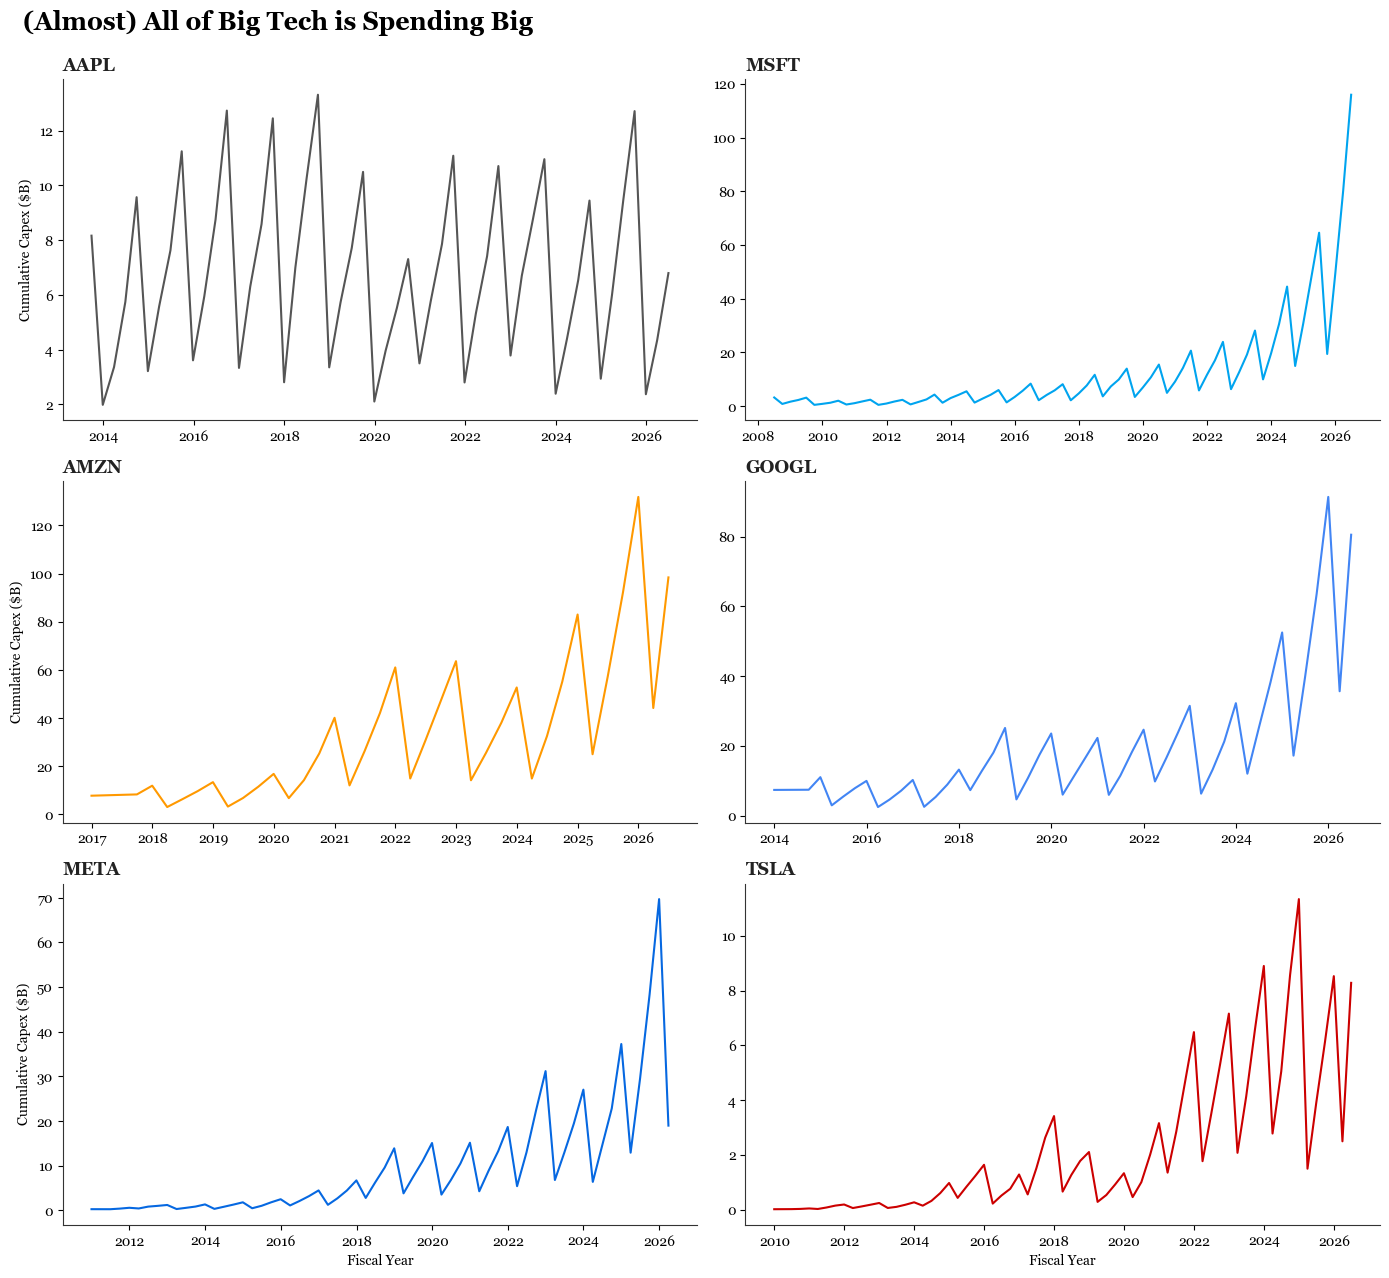

In [5]:
capex_dict = {ticker: df[1] for ticker, df in zip(tickers, dfs)}
capex_tags = {'AAPL': 'PaymentsToAcquirePropertyPlantAndEquipment', 'MSFT': 'PaymentsToAcquirePropertyPlantAndEquipment', 'AMZN': 'PaymentsToAcquireProductiveAssets', 'GOOGL': 'PaymentsToAcquirePropertyPlantAndEquipment', 'META': 'PaymentsToAcquirePropertyPlantAndEquipment', 'TSLA': 'PaymentsToAcquirePropertyPlantAndEquipment'}

colors = {
    'AAPL': '#555555', 'MSFT': '#00A4EF', 'AMZN': '#FF9900',
    'GOOGL': '#4285F4', 'META': '#0668E1', 'TSLA': '#CC0000' }

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, ticker in enumerate(capex_dict.keys()):
    axes[i].plot(capex_dict[ticker]['end'], capex_dict[ticker][capex_tags[ticker]]/1e9, color=colors[ticker])
    axes[i].set_title(ticker, loc='left', fontsize=13, fontweight='bold', color='#222222')

    if i%2==0:
        axes[i].set_ylabel('Cumulative Capex ($B)')

    if (i==4) or (i==5):
        axes[i].set_xlabel('Fiscal Year')


axes[6].remove()
axes[7].remove()

fig.tight_layout()
fig.suptitle('(Almost) All of Big Tech is Spending Big', fontsize=18, fontweight='bold',
             x=0.02, ha='left', y=1.02)

plt.savefig('capex.png', dpi=300, bbox_inches='tight')

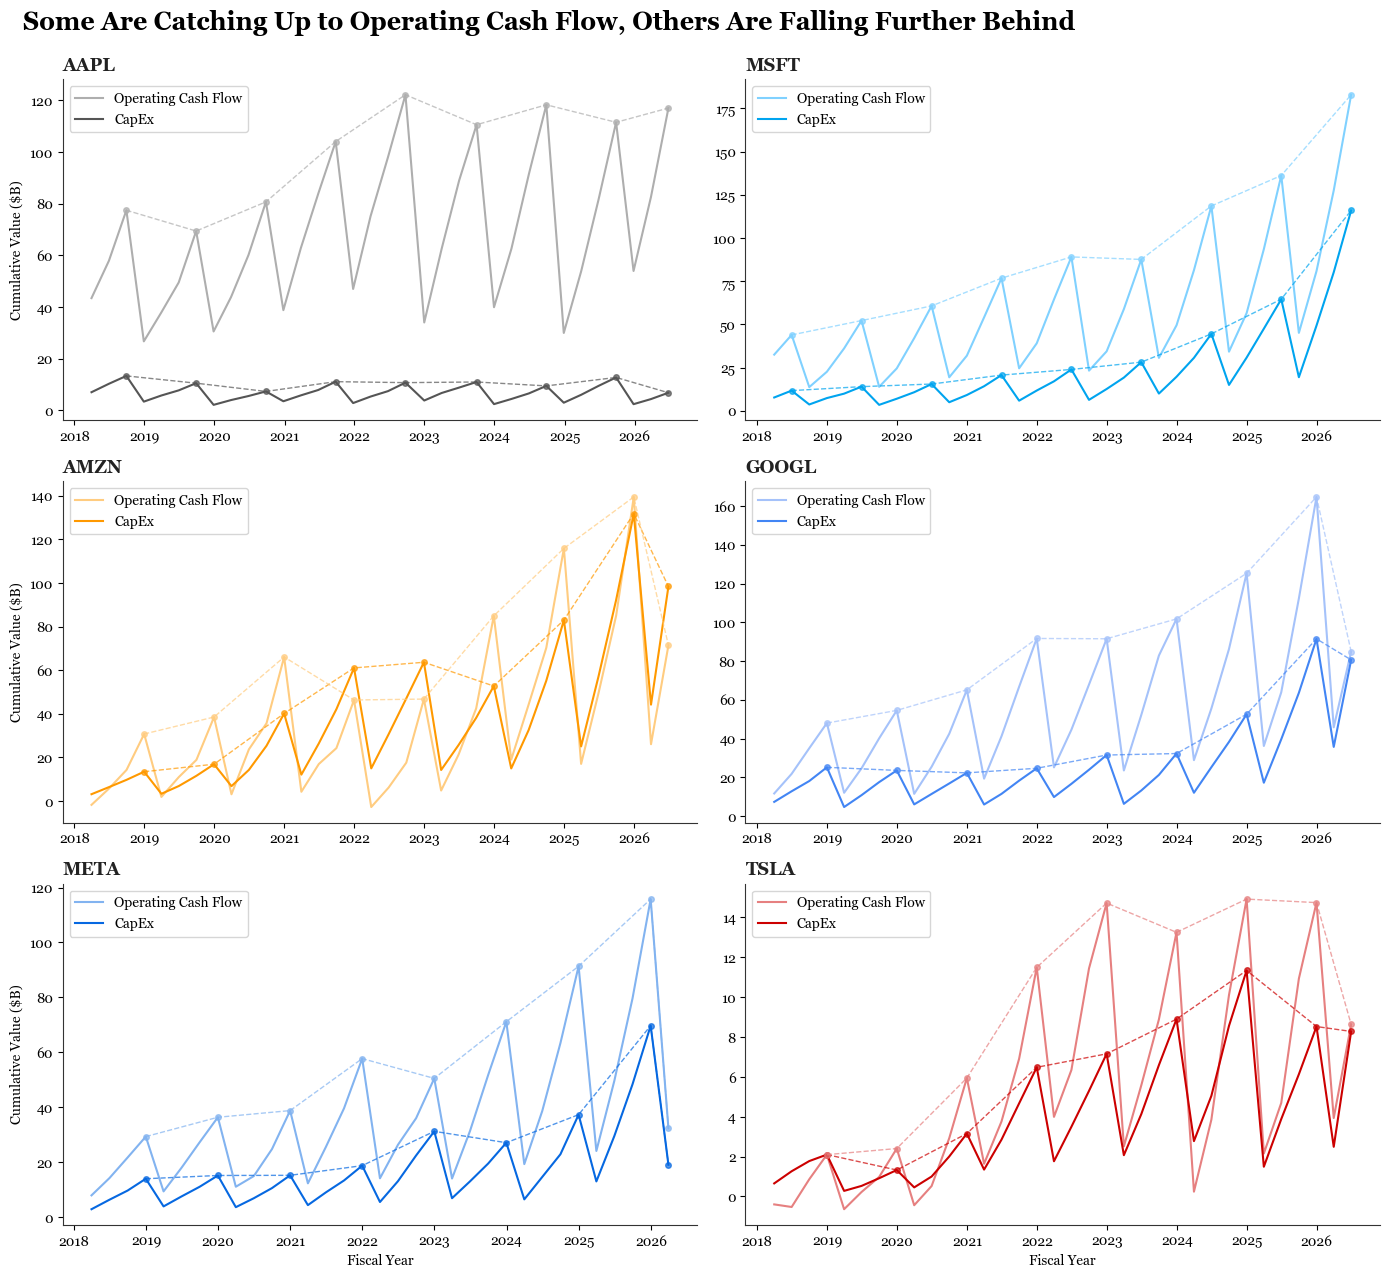

In [23]:
ocf_dict = {ticker: df[2] for ticker, df in zip(tickers, dfs)}
ocf_tag = 'NetCashProvidedByUsedInOperatingActivities'

colors = {
    'AAPL': '#555555', 'MSFT': '#00A4EF', 'AMZN': '#FF9900',
    'GOOGL': '#4285F4', 'META': '#0668E1', 'TSLA': '#CC0000' }
colors_light = {
    'AAPL': '#AEAEAE',
    'MSFT': '#80D1FF',
    'AMZN': '#FFCC80',
    'GOOGL': '#A5C2FA',
    'META': '#82B3F0',
    'TSLA': '#E68080'
}

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, ticker in enumerate(capex_dict.keys()):
    capex_df = capex_dict[ticker][capex_dict[ticker]['end'] >= '2018-01-01']
    ocf_df = ocf_dict[ticker][ocf_dict[ticker]['end'] >= '2018-01-01']
    
    axes[i].plot(ocf_df['end'], ocf_df[ocf_tag]/1e9, label='Operating Cash Flow', color=colors_light[ticker])
    axes[i].plot(capex_df['end'], capex_df[capex_tags[ticker]]/1e9, label='CapEx', color=colors[ticker])
    axes[i].set_title(ticker, loc='left', fontsize=13, fontweight='bold', color='#222222')
    axes[i].legend(loc='upper left')



    # peak (max cumulative value) per fiscal year for CapEx
    capex_df['value'] = capex_df[capex_tags[ticker]]/1e9
    capex_peaks = capex_df.loc[capex_df.groupby(capex_df['end'].dt.year)['value'].idxmax()]
    axes[i].plot(capex_peaks['end'], capex_peaks['value'], color=colors[ticker],
                 linestyle='--', linewidth=1, marker='o', markersize=4, alpha=0.7)

    # peak (max cumulative value) per fiscal year for OCF
    ocf_df['value'] = ocf_df[ocf_tag]/1e9
    ocf_peaks = ocf_df.loc[ocf_df.groupby(ocf_df['end'].dt.year)['value'].idxmax()]
    axes[i].plot(ocf_peaks['end'], ocf_peaks['value'], color=colors_light[ticker],
                 linestyle='--', linewidth=1, marker='o', markersize=4, alpha=0.7)

    if i%2==0:
        axes[i].set_ylabel('Cumulative Value ($B)')

    if (i==4) or (i==5):
        axes[i].set_xlabel('Fiscal Year')


axes[6].remove()
axes[7].remove()

fig.tight_layout()
fig.suptitle('Some Are Catching Up to Operating Cash Flow, Others Are Falling Further Behind', fontsize=18, fontweight='bold',
             x=0.02, ha='left', y=1.02)

plt.savefig('ocf.png', dpi=300, bbox_inches='tight')

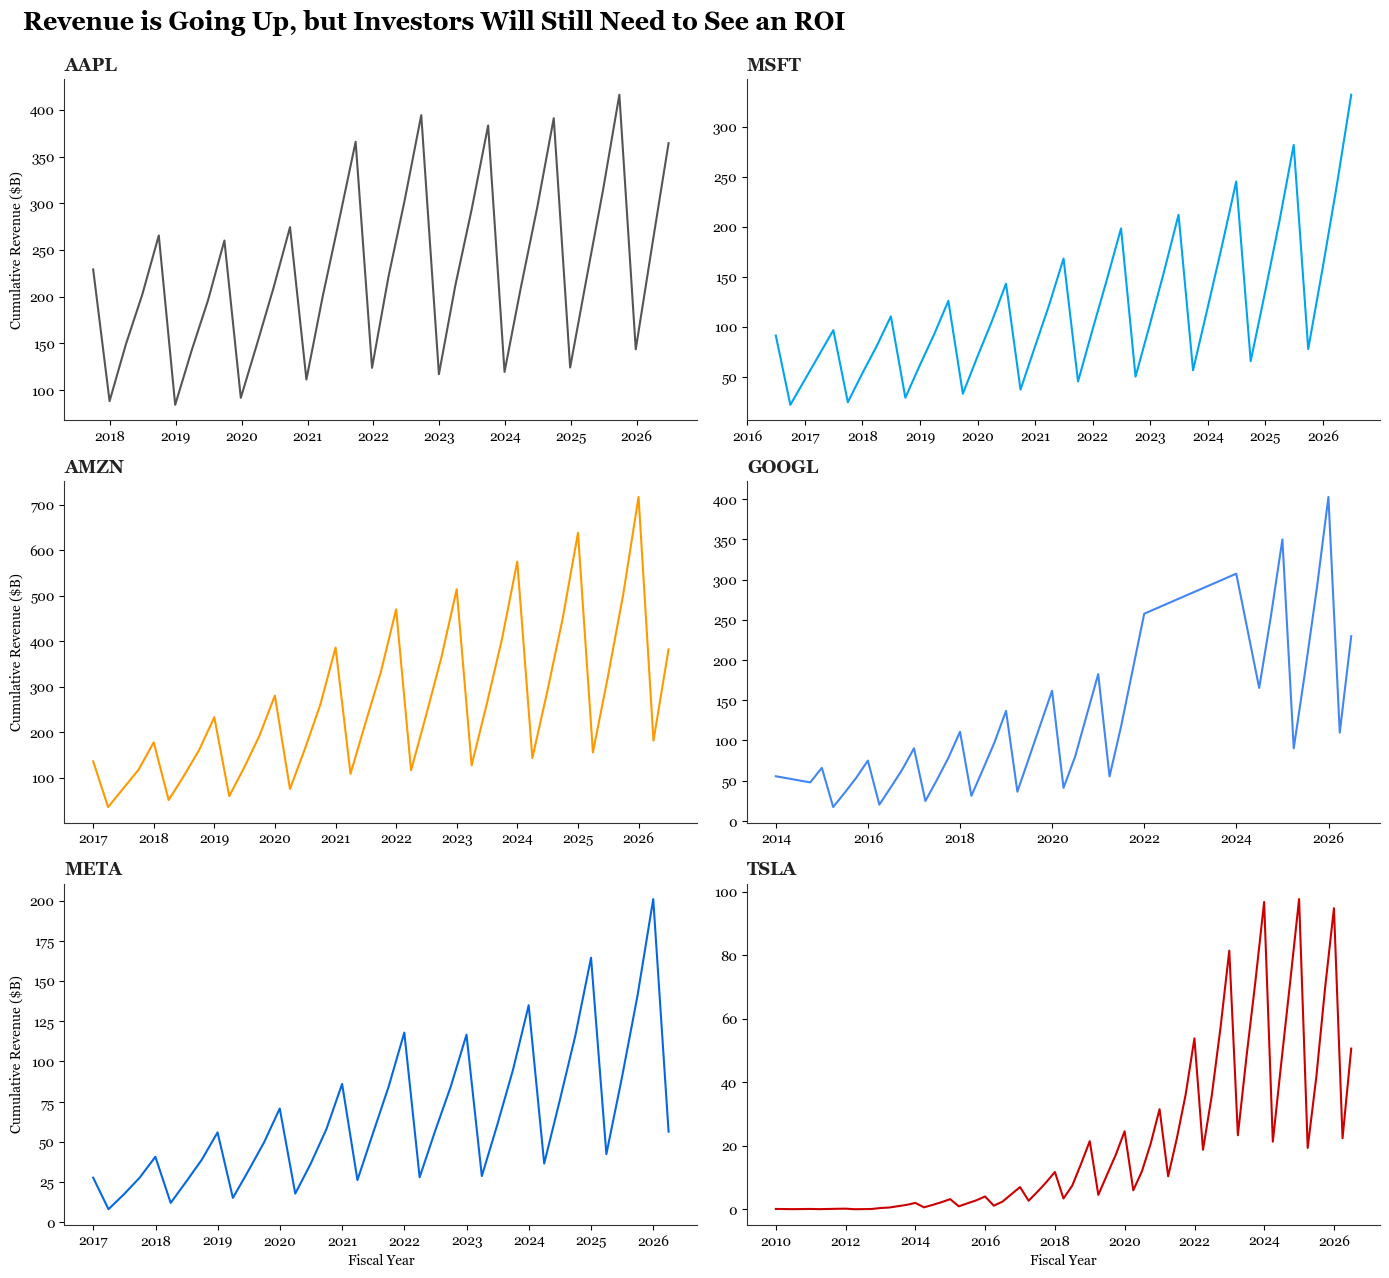

In [26]:
rev_dict = {ticker: df[0] for ticker, df in zip(tickers, dfs)}
rev_tags = {'AAPL': 'RevenueFromContractWithCustomerExcludingAssessedTax', 'MSFT': 'RevenueFromContractWithCustomerExcludingAssessedTax', 'AMZN': 'RevenueFromContractWithCustomerExcludingAssessedTax', 'GOOGL': 'Revenues', 'META': 'RevenueFromContractWithCustomerExcludingAssessedTax', 'TSLA': 'Revenues'}

colors = {
    'AAPL': '#555555', 'MSFT': '#00A4EF', 'AMZN': '#FF9900',
    'GOOGL': '#4285F4', 'META': '#0668E1', 'TSLA': '#CC0000' }

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, ticker in enumerate(capex_dict.keys()):
    axes[i].plot(rev_dict[ticker]['end'], rev_dict[ticker][rev_tags[ticker]]/1e9, color=colors[ticker])
    axes[i].set_title(ticker, loc='left', fontsize=13, fontweight='bold', color='#222222')

    if i%2==0:
        axes[i].set_ylabel('Cumulative Revenue ($B)')

    if (i==4) or (i==5):
        axes[i].set_xlabel('Fiscal Year')


axes[6].remove()
axes[7].remove()

fig.tight_layout()
fig.suptitle('Revenue is Going Up, but Investors Will Still Need to See an ROI', fontsize=18, fontweight='bold',
             x=0.02, ha='left', y=1.02)

plt.savefig('revenue.png', dpi=300, bbox_inches='tight')